> **MobileNet v2**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from sklearn.model_selection import train_test_split
from PIL import Image

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.layers.experimental import preprocessing

# System libraries
from pathlib import Path
import os.path

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

--2023-04-16 07:57:44--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2023-04-16 07:57:45 (60.2 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = (320, 320)
dataset = "/kaggle/input/pest-normalized"

image_dir = Path(dataset)

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpeg')) + list(image_dir.glob(r'**/*.png'))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

print(len(list(image_dir.glob(r'**/*.jpeg'))))

image_df

1669


,Filepath,Label
0,/kaggle/input/pest-normalized/Gall.Flies/GallF...,Gall.Flies
1,/kaggle/input/pest-normalized/Gall.Flies/GallF...,Gall.Flies
2,/kaggle/input/pest-normalized/Gall.Flies/GallF...,Gall.Flies
3,/kaggle/input/pest-normalized/Gall.Flies/GallF...,Gall.Flies
4,/kaggle/input/pest-normalized/Gall.Flies/GallF...,Gall.Flies
...,...,...
1664,/kaggle/input/pest-normalized/Stem.Borer/StemB...,Stem.Borer
1665,/kaggle/input/pest-normalized/Stem.Borer/StemB...,Stem.Borer
1666,/kaggle/input/pest-normalized/Stem.Borer/StemB...,Stem.Borer
1667,/kaggle/input/pest-normalized/Stem.Borer/StemB...,Stem.Borer


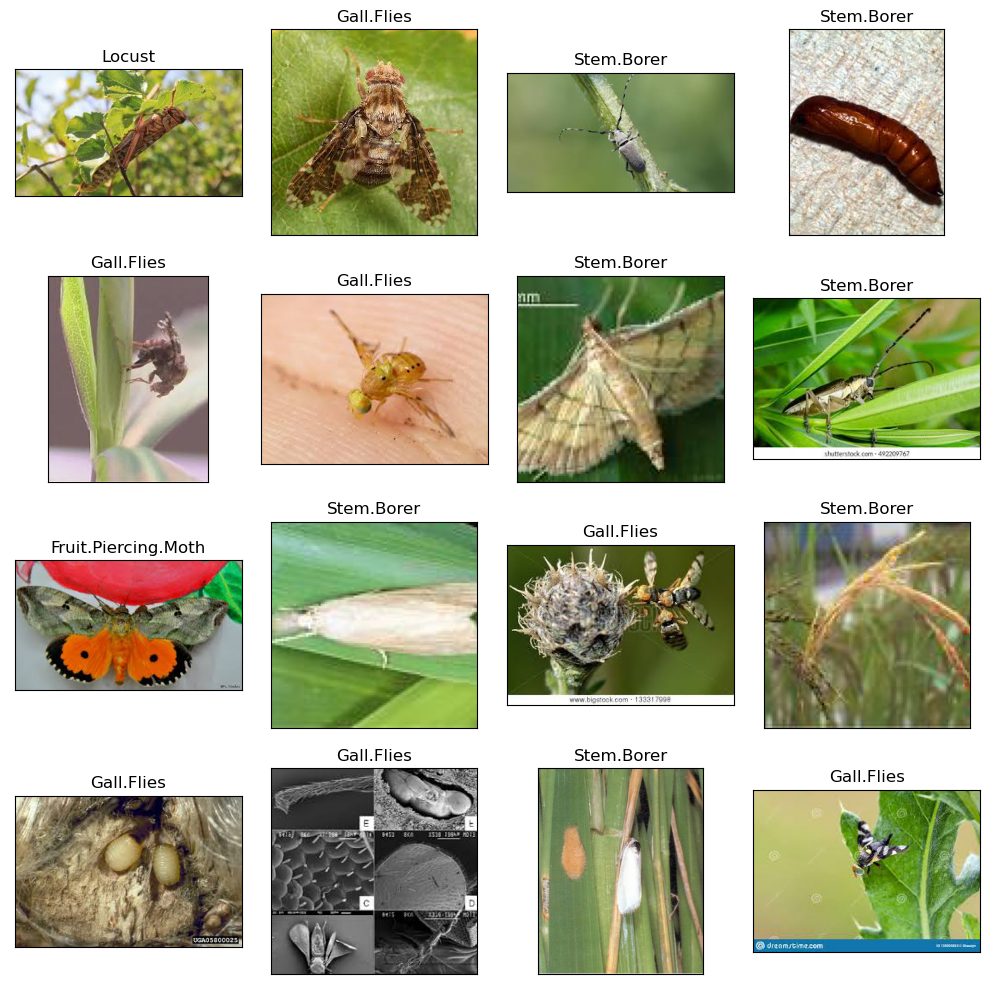

In [4]:
import matplotlib.image as mpimg
# Display 16 picture of the dataset with their labels
random_index = np.random.randint(0, len(image_df), 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    image = Image.open(image_df.Filepath[random_index[i]])
    ax.imshow(image)
    ax.set_title(image_df.Label[random_index[i]])
plt.tight_layout()
plt.show()

In [5]:
train_df, test_df = train_test_split(image_df, test_size=0.2, shuffle=True, random_state=42)
train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [6]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 1068 validated image filenames belonging to 4 classes.
Found 267 validated image filenames belonging to 4 classes.
Found 334 validated image filenames belonging to 4 classes.


In [7]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(224,224),
  layers.experimental.preprocessing.Rescaling(1./255),
])

pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 [==============================] - 0s 0us/step


In [8]:
checkpoint_path = "/kaggle/working/20Epochs/pest_classification_mobileNetv2_checkpoint"
checkpoint_callback = ModelCheckpoint(checkpoint_path,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True)

early_stopping = EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True)

In [9]:
inputs = pretrained_model.input
x = resize_and_rescale(inputs)

x = Dense(256, activation='relu')(pretrained_model.output)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=20,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", 
                                    "pest_classification"),
        checkpoint_callback,
    ]
)

Saving TensorBoard log files to: training_logs/pest_classification/20230416-075751
Epoch 1/20
34/34 [==============================] - 23s 424ms/step - loss: 1.2881 - accuracy: 0.4176 - val_loss: 1.0273 - val_accuracy: 0.6330
Epoch 2/20
34/34 [==============================] - 9s 269ms/step - loss: 0.9408 - accuracy: 0.6629 - val_loss: 0.8370 - val_accuracy: 0.6929
Epoch 3/20
34/34 [==============================] - 9s 258ms/step - loss: 0.7495 - accuracy: 0.7406 - val_loss: 0.6916 - val_accuracy: 0.7603
Epoch 4/20
34/34 [==============================] - 9s 281ms/step - loss: 0.6170 - accuracy: 0.7818 - val_loss: 0.6098 - val_accuracy: 0.7715
Epoch 5/20
34/34 [==============================] - 9s 254ms/step - loss: 0.5446 - accuracy: 0.8240 - val_loss: 0.5550 - val_accuracy: 0.7978
Epoch 6/20
34/34 [==============================] - 9s 266ms/step - loss: 0.4623 - accuracy: 0.8483 - val_loss: 0.5181 - val_accuracy: 0.8127
Epoch 7/20
34/34 [==============================] - 9s 272ms/ste

In [10]:
model.save("/kaggle/working/pest_classification_mobileNetv2_20epochs.h5")

In [11]:
results = model.evaluate(test_images, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.47177
Test Accuracy: 85.03%


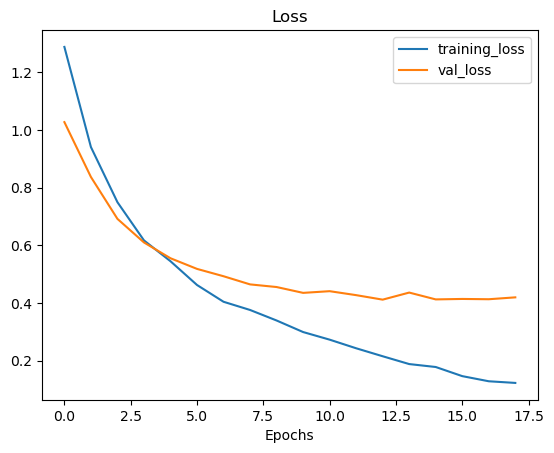

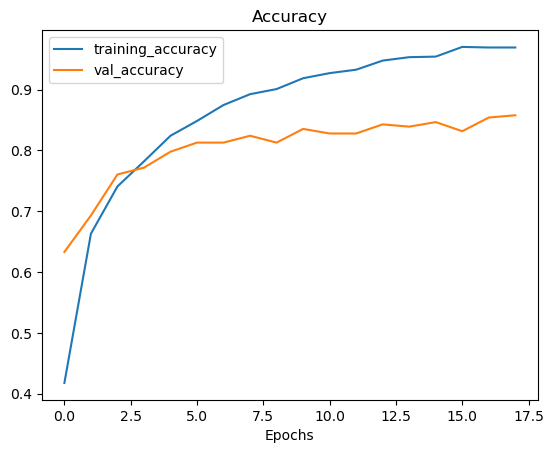

In [12]:
plot_loss_curves(history)

In [13]:
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

# Display the result
print(f'The first 5 predictions: {pred[:5]}')

11/11 [==============================] - 3s 167ms/step
The first 5 predictions: ['Stem.Borer', 'Fruit.Piercing.Moth', 'Gall.Flies', 'Stem.Borer', 'Stem.Borer']


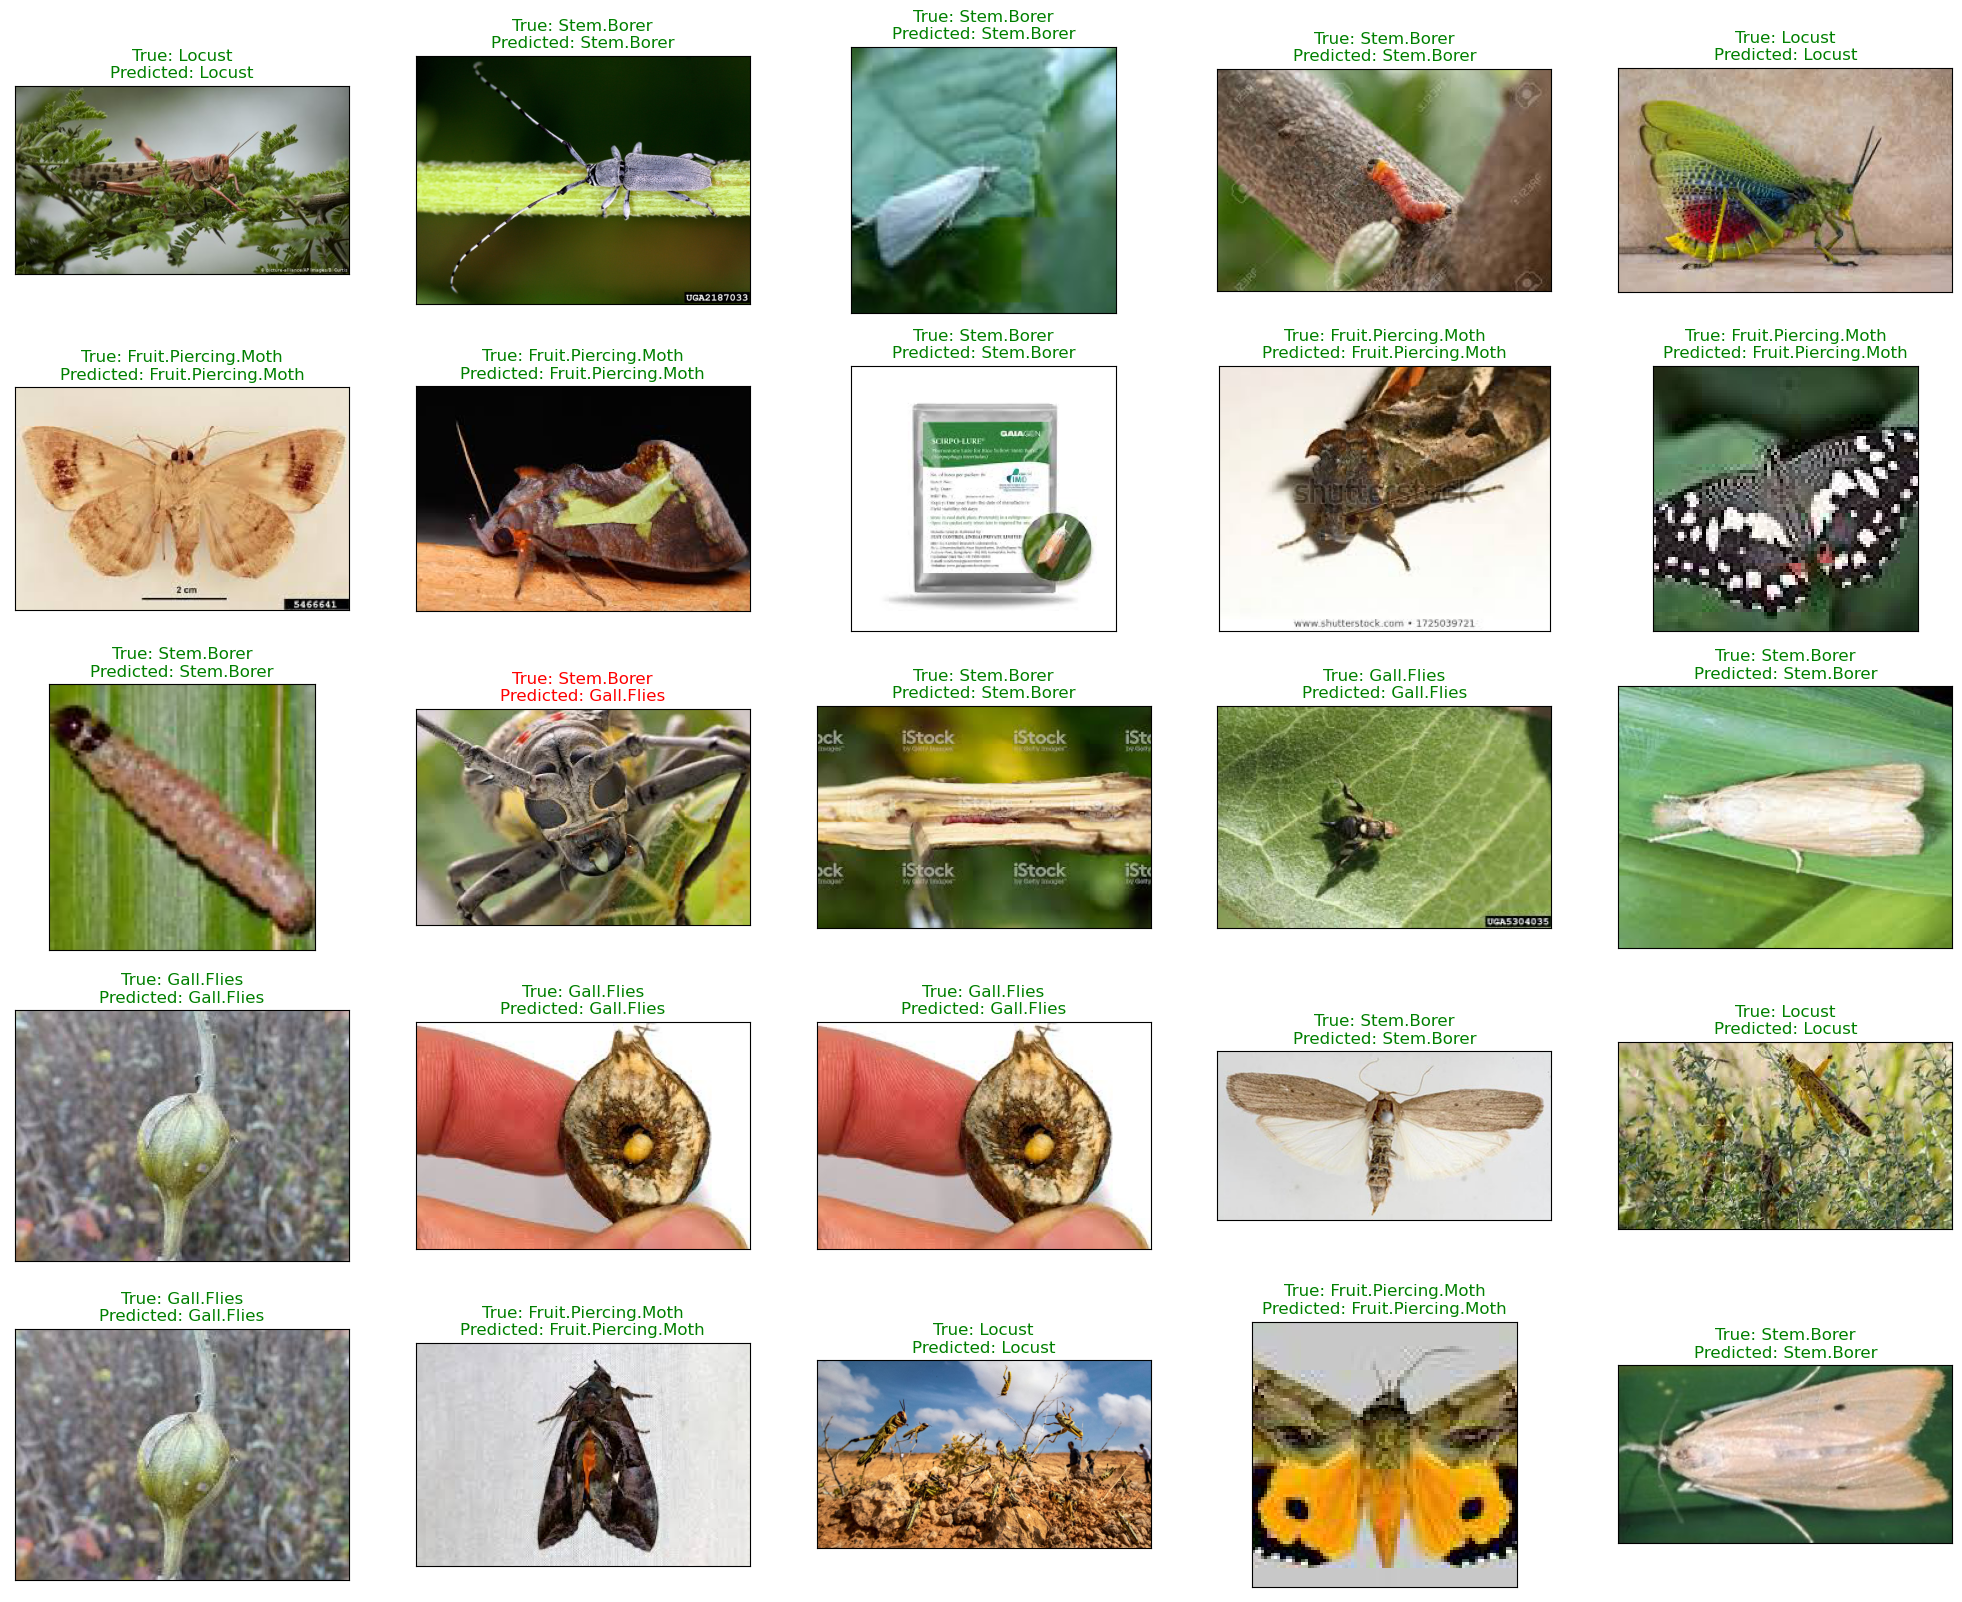

<Figure size 640x480 with 0 Axes>

In [14]:
random_index = np.random.randint(0, len(test_df) - 1, 25)
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25, 20),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    image = Image.open(test_df.Filepath.iloc[random_index[i]])
    ax.imshow(image)
    if test_df.Label.iloc[random_index[i]] == pred[random_index[i]]:
      color = "green"
    else:
      color = "red"
    ax.set_title(f"True: {test_df.Label.iloc[random_index[i]]}\nPredicted: {pred[random_index[i]]}", color=color)
plt.show()
plt.tight_layout()

In [15]:
y_test = list(test_df.Label)
print(classification_report(y_test, pred))

report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()
df

                     precision    recall  f1-score   support

Fruit.Piercing.Moth       0.82      0.80      0.81        74
         Gall.Flies       0.88      0.84      0.86       108
             Locust       0.94      0.88      0.91        67
         Stem.Borer       0.79      0.88      0.83        85

           accuracy                           0.85       334
          macro avg       0.86      0.85      0.85       334
       weighted avg       0.85      0.85      0.85       334



,precision,recall,f1-score,support
Fruit.Piercing.Moth,0.819444,0.797297,0.808219,74.000000
Gall.Flies,0.875000,0.842593,0.858491,108.000000
Locust,0.936508,0.880597,0.907692,67.000000
Stem.Borer,0.789474,0.882353,0.833333,85.000000
accuracy,0.850299,0.850299,0.850299,0.850299
macro avg,0.855107,0.850710,0.851934,334.000000
weighted avg,0.853264,0.850299,0.850820,334.000000
